## Idea
I want to build a shortest path analysis of routes people would take from their home to work (the subway) in Grasshopper. The datasets I am going to use are the subway station locations from the MTA, street centerlines from NYC Open Data and building census according to tax lots. The reason I ended up choosing centerlines and not OpenStreet Maps was because 
    A) I wasnt aware of the dataset initially, particularly the sidewalk paths that were included in the dataset. Good to know because I ended up doing a fun but circuitous option that you can explore here (/Users/temp/Documents/GitHub/cdp-mapping-systems/Personal Work/Pathmapping_Tool/NYCPathways_1stTry.ipynb). The short story of this build was attempting to construct centerlines of park paths from the NYC Planimetric Database. Basically making a centerline from the middle of the polygon. It "worked" but when I uploaded to Grasshopper it ended up being a collection of a bunch of small lines, making the computational load very heavy.
    B) -and a big reason for not switching to the OpenStreet data once I learned about it was because I did not want the visualization to be too crowded in Grasshopper. My thought was, viewed from a neighborhood scale like Bed-Stuy individual paths on each side of a street would end up being visually confusing and miss the analysis. Maybe once particular "high intereaction streets" are identified I could point zoom into these sections and show if there is any nuance per street. 

Another obstacle I ran into was the files could not be too large in order for Grasshopper to run an analysis. This is something I'm learning and I'm curious on your take of at what scale does it make sense to switch frrom an analysis in Grasshopper to one using Python.

## Subway Points

So! We start. Here I am loading my data

In [1]:
import geopandas as gpd
from shapely.validation import make_valid

IN_PATH  = "/Users/temp/Documents/GitHub/cdp-mapping-systems/Personal Work/Pathmapping_Tool/Data/MTA_Subway_Stations_20260723.geojson"
OUT_PATH = "/Users/temp/Documents/GitHub/cdp-mapping-systems/Personal Work/Pathmapping_Tool/outputs/subway_stops.geojson"

Now I am "trimming it". I went ahead and defined by borough. Its much larger than just the neighborhoods of Bed-Stuy and Jackson Heights but: 
    A) There was not a neighborhood specific categorization of the data
    B) There are not that many points in the dataset relative to bigger datasets
    c) I wanted to account for subways stations that might be just outside of the neighborhood boundry in order to properly capture options for commuting

In [2]:
gdf = gpd.read_file(IN_PATH) #This is defining gdf as something that is reading the GeoJSON file In_Path. 
gdf = gdf[gdf["borough"].isin(["Bk", "Q"])] #This is filtering by bourough and specifically looking for the Brooklyn and Queens identifiers. This is essentially a serch and filter function.
gdf["geometry"] = gdf.geometry.apply(lambda g: make_valid(g) if g is not None else g) #This idea i'm still getting to understand. It is removing any invalid geometries. Curious on "how" it does this through the Lambda function.
gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty] # This is filtering out any rows that have a null geometry or an empty geometry.

In [3]:
print(f"Exporting {len(gdf)} stations") #This I get. Print the number below
gdf.to_file(OUT_PATH, driver="GeoJSON")
print("Done.")

Exporting 252 stations
Done.


## Centerline

Pretty much the same thing here. Except here I'm cutting up the data into Bed-Stuy, Jackson Heights and just a normal Centerline. Previously I had defined the bounds for each neighborhood. I am adding a mile to each in order to make sure there are not any weird cutoffs. 

In [4]:
import geopandas as gpd
from shapely.validation import make_valid

IN_PATH  = "/Users/temp/Documents/GitHub/cdp-mapping-systems/Personal Work/Pathmapping_Tool/outputs/Centerline.geojson"
OUT_PATH = "/Users/temp/Documents/GitHub/cdp-mapping-systems/Personal Work/Pathmapping_Tool/outputs/Centerline.geojson"
BEDSTUY_PATH = "/Users/temp/Documents/GitHub/cdp-mapping-systems/Personal Work/Pathmapping_Tool/Data/boundary_bedstuy.geojson"
JACKSON_PATH = "/Users/temp/Documents/GitHub/cdp-mapping-systems/Personal Work/Pathmapping_Tool/Data/boundary_jacksonheights.geojson"

WALK_15MIN_FT = 3960  # 15 min walk @ 3 mph (264 ft/min × 15)

bedstuy = gpd.read_file(BEDSTUY_PATH)
jackson = gpd.read_file(JACKSON_PATH)

study_area = gpd.GeoSeries(     #This is defining the study area.
    [bedstuy.geometry.iloc[0].buffer(WALK_15MIN_FT), jackson.geometry.iloc[0].buffer(WALK_15MIN_FT)],
    crs=bedstuy.crs,    #Referring to the BedStuy crs to define this new area.
).union_all()

cl = gpd.read_file(IN_PATH) #I was running into some in Grasshoppper and a potential issue might've been clipped data. So this is an attempt to clean that up.
cl_2263 = cl.to_crs(bedstuy.crs)
cl_2263 = cl_2263[cl_2263.geometry.intersects(study_area)]

cl_2263["geometry"] = cl_2263.geometry.apply(lambda g: make_valid(g) if g is not None else g)
cl_2263 = cl_2263[cl_2263.geometry.notna() & ~cl_2263.geometry.is_empty]

cl_out = cl_2263.to_crs("EPSG:4326")

print(f"Exporting {len(cl_out)} segments")
cl_out.to_file(OUT_PATH, driver="GeoJSON")
print("Done.")

Exporting 8014 segments
Done.


/var/folders/jm/2cq5x30j3gx977bqk1tjsk0r0000gn/T/ipykernel_50870/1282262131.py:24: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


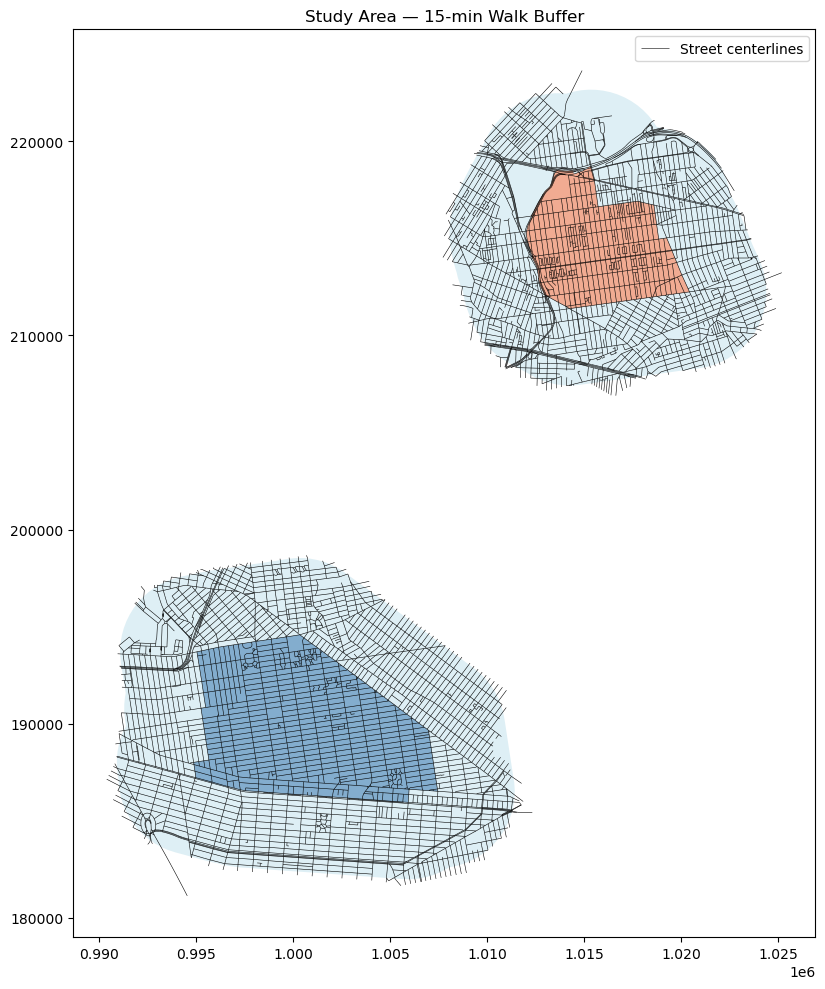

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

# Plot the buffer zone
gpd.GeoSeries([study_area], crs=bedstuy.crs).plot(
    ax=ax, color='lightblue', alpha=0.4, label='15-min walk buffer'
)

# Plot original neighborhood boundaries
bedstuy.to_crs(bedstuy.crs).plot(
    ax=ax, color='steelblue', alpha=0.6, label='Bed-Stuy'
)
jackson.to_crs(bedstuy.crs).plot(
    ax=ax, color='coral', alpha=0.6, label='Jackson Heights'
)

# Plot the clipped centerlines
cl_2263.plot(
    ax=ax, color='black', linewidth=0.4, label='Street centerlines'
)

ax.set_title("Study Area — 15-min Walk Buffer")
ax.legend()
plt.tight_layout()
plt.show()

## Splitting into per-neighborhood centerlines

The file above still covers both neighborhoods combined within a 1-mile buffer, which is why it's still large enough to trip up Grasshopper's GeoJSON reader. Reuse `cl_2263` (already validated/repaired above) and clip it to each neighborhood's own 15-minute walk buffer (not the raw boundary, and not the combined `study_area`) — then export separately so Grasshopper only has to load what it needs at a time.

In [ ]:
BEDSTUY_OUT = "/Users/temp/Documents/GitHub/cdp-mapping-systems/Personal Work/Pathmapping_Tool/outputs/centerline_bedstuy.geojson"
JACKSON_OUT = "/Users/temp/Documents/GitHub/cdp-mapping-systems/Personal Work/Pathmapping_Tool/outputs/centerline_jacksonheights.geojson"

bedstuy_buffer = gpd.GeoSeries([bedstuy.geometry.iloc[0].buffer(WALK_15MIN_FT)], crs=bedstuy.crs)
jackson_buffer = gpd.GeoSeries([jackson.geometry.iloc[0].buffer(WALK_15MIN_FT)], crs=jackson.crs)

for boundary, out_path, label in [
    (bedstuy_buffer, BEDSTUY_OUT, "bedstuy"),
    (jackson_buffer, JACKSON_OUT, "jacksonheights"),
]:
    clipped = gpd.clip(cl_2263, boundary)
    clipped = clipped.to_crs("EPSG:4326")
    print(f"{label}: {len(clipped)} segments -> {out_path}")
    clipped.to_file(out_path, driver="GeoJSON")

In [7]:
import geopandas as gpd

path = "/Users/temp/Documents/GitHub/cdp-mapping-systems/Personal Work/Pathmapping_Tool/outputs/centerline_bedstuy.geojson"

gdf = gpd.read_file(path)
print(gdf.crs)
print(gdf.total_bounds)

EPSG:4326
[-73.96167057  40.67701849 -73.91630268  40.70042457]


In [8]:
gdf = gpd.read_file("/Users/temp/Documents/GitHub/cdp-mapping-systems/Personal Work/Pathmapping_Tool/outputs/centerline_bedstuy.geojson")
print(gdf.geometry.geom_type.value_counts())

LineString         1072
MultiLineString       4
Name: count, dtype: int64


In [9]:
print(len(gdf))

1076


And just like that! There is data ready for Grasshopper Analysis.